In [2]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 2
METRICS_NOTES = "PCA"

UPDATE_DATABASE = True

LOG_TRANSFORM_COLS = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency', 
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])

# Results

In [21]:
from shared_util.fetch import fetch_metric

pca_results_df = fetch_metric(run_id=METRICS_DB_ID).sort_values(by='roc_auc', ascending=False)
results_df = fetch_metric(run_id=1).sort_values(by='roc_auc', ascending=False)


results_df[results_df['data'] == 'test'].head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,created_at
0,35,1,xgb,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.675963,0.472337,0.128680,0.767159,0.220392,4709.0,883.0,5979.0,268.0,2025-10-27 23:41:10.147287
11,24,1,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674749,0.264465,0.109538,0.920938,0.195789,2071.0,1060.0,8617.0,91.0,2025-10-27 23:23:22.331265
4,31,1,svc,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674099,0.418954,0.122263,0.805387,0.212298,4033.0,927.0,6655.0,224.0,2025-10-27 23:36:02.302171
7,28,1,sgd,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.669999,0.421995,0.122847,0.805387,0.213177,4069.0,927.0,6619.0,224.0,2025-10-27 23:24:32.414371


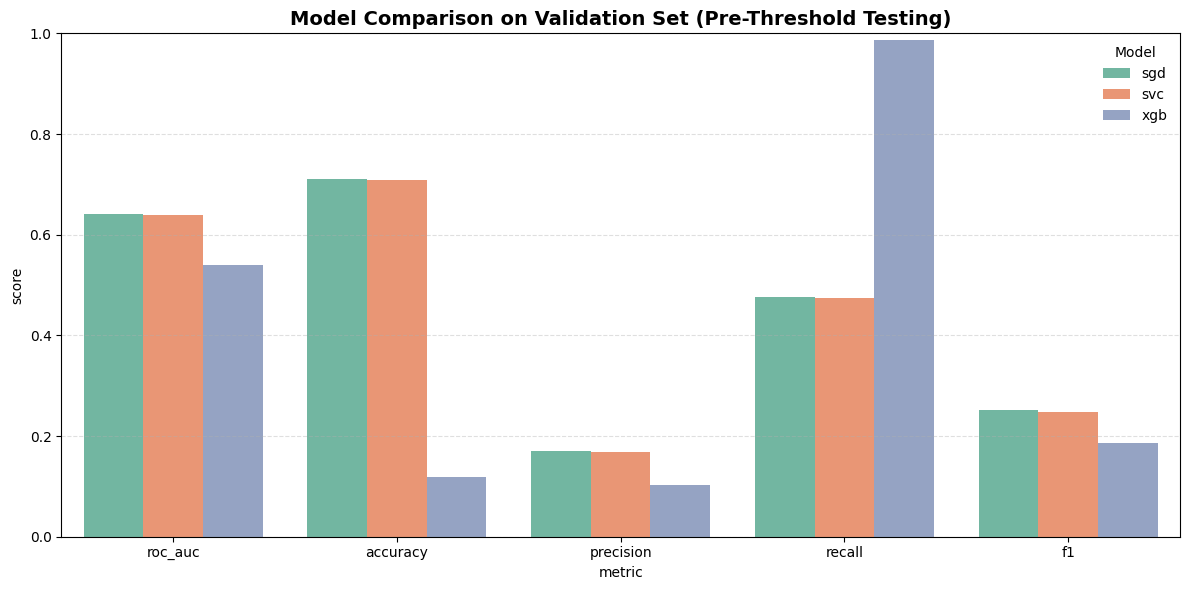

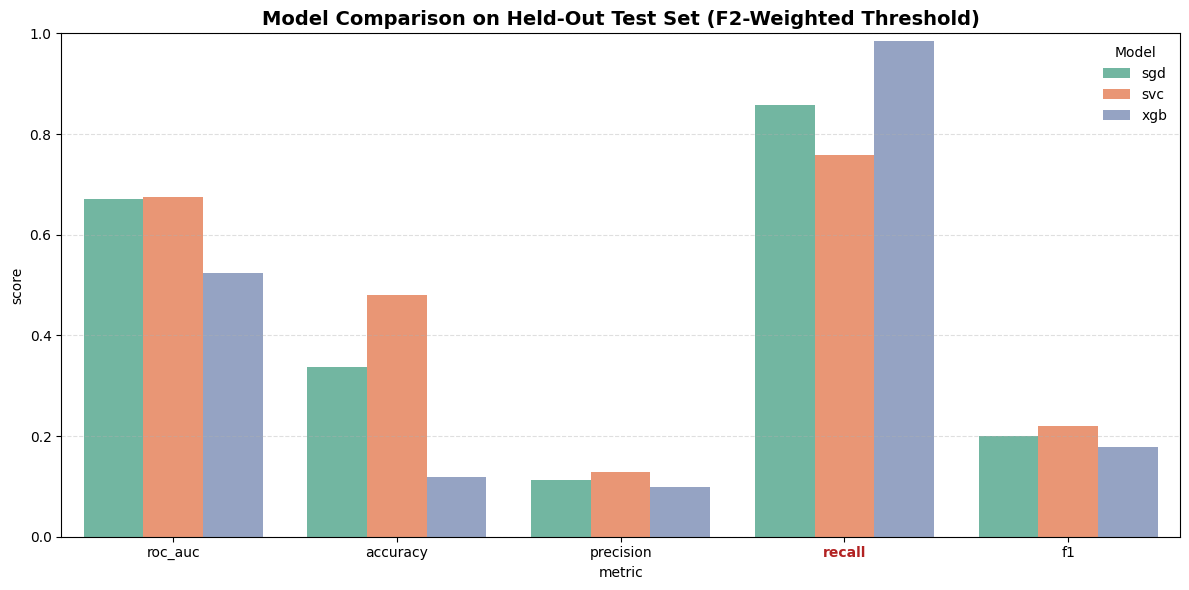

In [22]:
from shared_util.results.results import summary_by_auc, summary_by_recall, plot_metrics

plot_metrics(pca_results_df, METRICS_DB_ID)

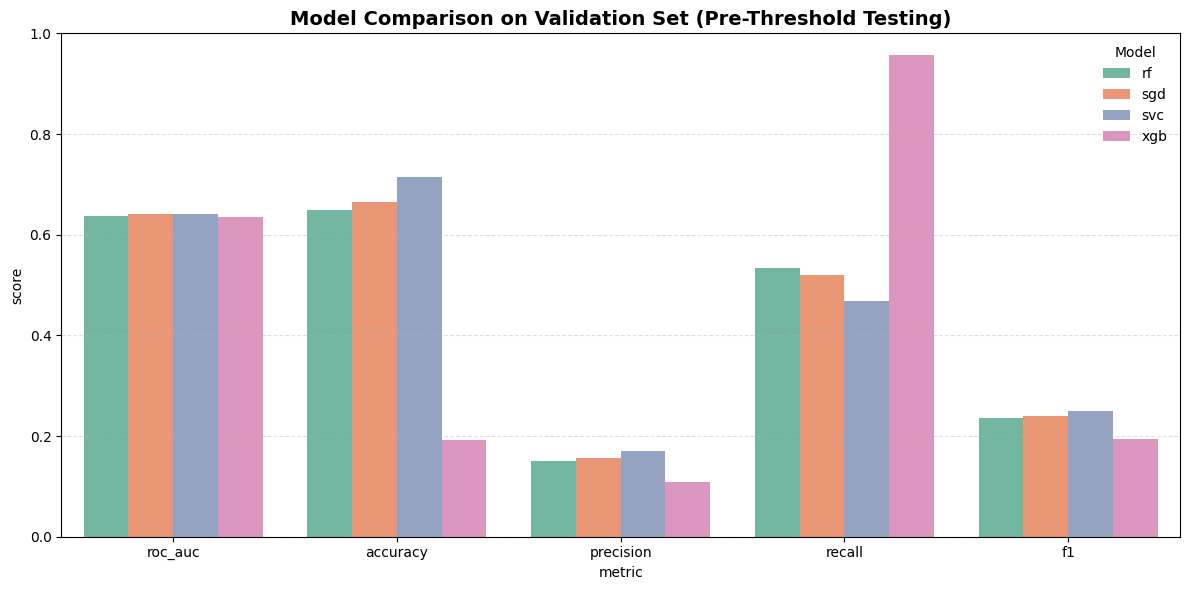

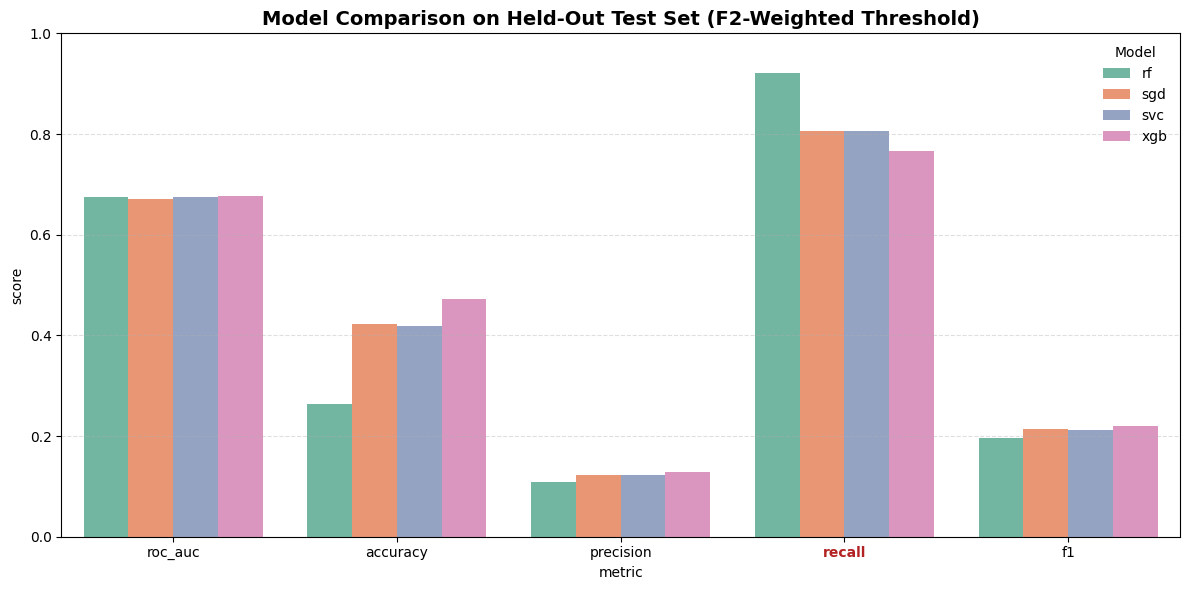

In [23]:
plot_metrics(results_df, 1)

In [25]:
print('--pca--')
summary_by_auc(pca_results_df, plot_id=METRICS_DB_ID)
summary_by_recall(pca_results_df)

print('--no pca--')
summary_by_auc(results_df, plot_id=1)
summary_by_recall(results_df)

--pca--
Models by ROC_AUC


,model,roc_auc
0,svc,0.675
1,sgd,0.671
10,xgb,0.525


Models by Recall


,model,recall
7,xgb,0.984
0,sgd,0.857
4,svc,0.758


--no pca--
Models by ROC_AUC


,model,roc_auc
0,xgb,0.676
1,rf,0.675
2,svc,0.674
3,sgd,0.670


Models by Recall


,model,recall
11,rf,0.921
7,sgd,0.805
4,svc,0.805
0,xgb,0.767


### Hyperparameter Display

In [18]:
from shared_util.fetch import fetch_hyperparams
import pandas as pd
import ast
import re

h_params_df = fetch_hyperparams(run_id=METRICS_DB_ID)

h_params_df.head(5)


_np_wrapper = re.compile(r"np\.(?:float|int)\d+\(([^)]+)\)")

def parse_hyperparams(text: str) -> pd.DataFrame:
    cleaned = _np_wrapper.sub(r"\1", text)
    params = ast.literal_eval(cleaned)

    def normalize(value):
        if isinstance(value, np.generic):
            return value.item()
        return value

    data = {k: normalize(v) for k, v in params.items()}
    return pd.DataFrame(data.items(), columns=["param", "value"])

for row in h_params_df.itertuples():
    print(f'Model: {row.model}')
    display(parse_hyperparams(row.hyperparam_text)) # type: ignore


Model: xgb


,param,value
0,model__colsample_bytree,0.702254
1,model__gamma,4.438850
2,model__learning_rate,0.256769
3,model__max_depth,2.000000
4,model__min_child_weight,8.000000
5,model__n_estimators,303.000000
6,model__reg_alpha,0.000176
7,model__reg_lambda,0.010656
8,model__scale_pos_weight,2.481276
9,model__subsample,0.831751


Model: svc


,param,value
0,model__C,0.631797
1,model__class_weight,balanced
2,model__gamma,0.001
3,model__kernel,rbf
4,model__shrinking,False


Model: sgd


,param,value
0,model__tol,0.0001
1,model__shuffle,True
2,model__penalty,l1
3,model__max_iter,500
4,model__loss,modified_huber
5,model__learning_rate,invscaling
6,model__l1_ratio,0.9
7,model__eta0,0.003
8,model__class_weight,None
9,model__average,10


Model: rf


,param,value
0,model__oob_score,False
1,model__n_estimators,100
2,model__min_samples_split,20
3,model__min_samples_leaf,4
4,model__max_features,0.2
5,model__max_depth,10
6,model__class_weight,balanced
7,model__bootstrap,True


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

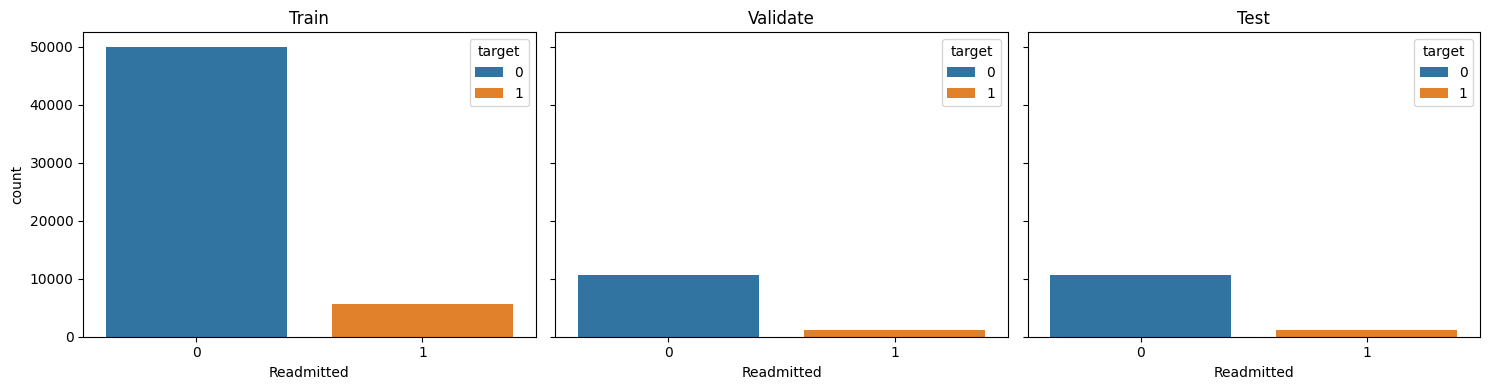

In [5]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scale=False,
    group_by_col='patient_nbr',
    create_interactions=False # no interaction terms for tree models
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [6]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.593 0.592 0.597 0.6   0.589]
mean roc_auc score: , 0.594
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.654 0.635 0.624 0.653 0.632]
mean roc_auc score: , 0.640
Duration: 0 hrs, 0 mins, 19.0 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
6,number_inpatient,0.067655,0.009661
5,number_emergency,0.006267,0.001169
3,num_medications,0.003834,0.003512
7,number_diagnoses,0.003263,0.003882
0,time_in_hospital,0.002859,0.002259
2,num_procedures,0.002400,0.002274
15,diag1_group_respiratory,0.002164,0.001035
1,num_lab_procedures,0.002108,0.001784
37,specialty_cat_cardiology,0.002038,0.000482
12,diag1_group_musculoskeletal,0.001686,0.000573


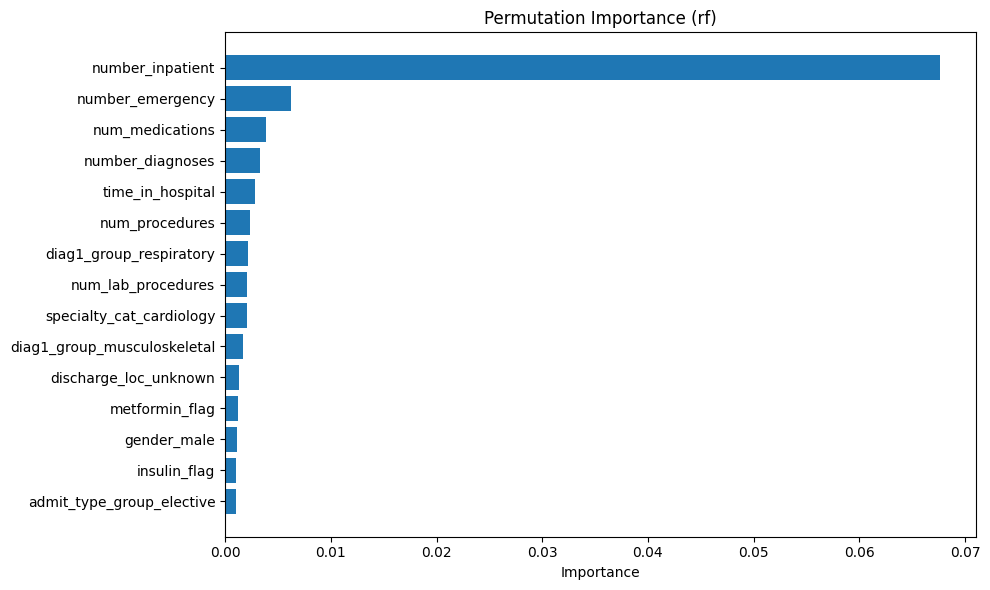

Duration: 0 hrs, 0 mins, 42.3 secs


In [7]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [8]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Best ROC_AUC (cv): 0.658743270492685
Best params: {'model__oob_score': False, 'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_features': 0.2, 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}
logged hyperparameters
Duration: 0 hrs, 0 mins, 32.2 secs


In [9]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6369706741016923
Accuracy:      0.6484578536011429
F1 score:      0.23598173515981735
Precision:     0.15139442231075698
Recall:        0.5347682119205298

Confusion matrix:

TN: 7070, FP: 3621, FN: 562, TP: 646

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77     10691
           1       0.15      0.53      0.24      1208

    accuracy                           0.65     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.65      0.72     11899



Best threshold (F2): 0.3734
Precision: 0.112  Recall: 0.913  F2: 0.376


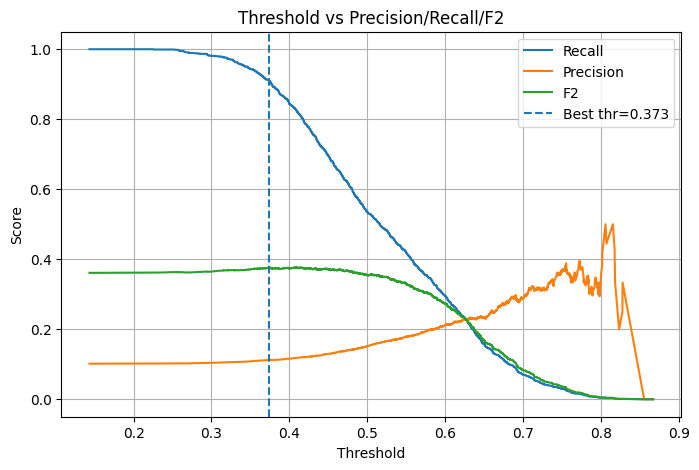

ROC_AUC:     0.674748705239391
Accuracy:      0.2644649041304164
F1 score:      0.1957886959734023
Precision:     0.10953807998346594
Recall:        0.9209383145091226

Confusion matrix:

TN: 2071, FP: 8617, FN: 91, TP: 1060

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.19      0.32     10688
           1       0.11      0.92      0.20      1151

    accuracy                           0.26     11839
   macro avg       0.53      0.56      0.26     11839
weighted avg       0.88      0.26      0.31     11839



In [10]:
model_pipe.test(
    use_f2_threshold=True,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

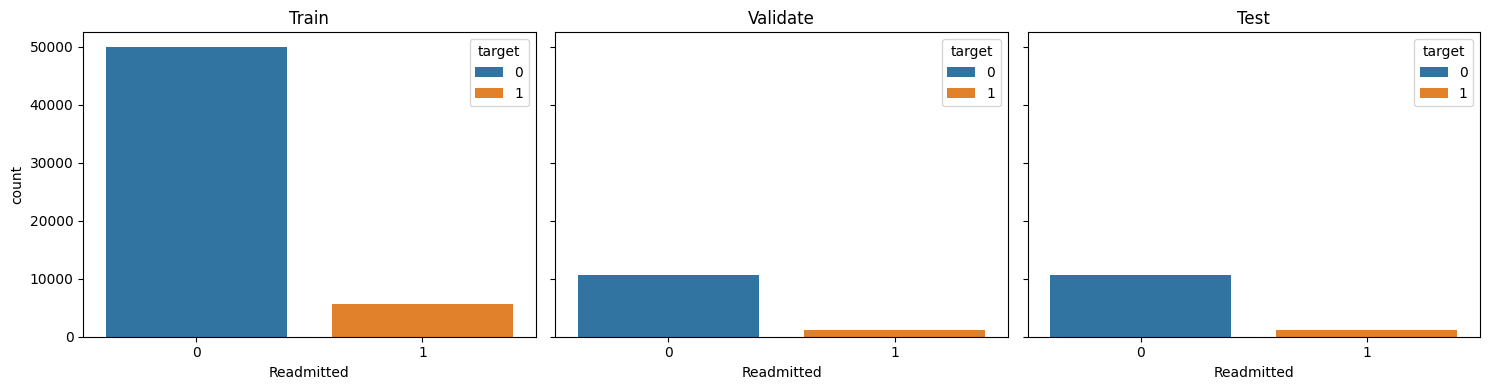

In [16]:
model = 'sgd' #SGDClassifier

PCA= True


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scale=True,
    use_pca=True
)



,feature,importance_mean,importance_std
6,number_inpatient,0.056626,0.010851
5,number_emergency,0.007278,0.002655
0,time_in_hospital,0.005379,0.004363
7,number_diagnoses,0.005019,0.001946
12,diag1_group_musculoskeletal,0.003909,0.001531
3,num_medications,0.003276,0.002170
54,diabetesMed_flag,0.002854,0.001576
58,num_drugs,0.001884,0.001780
4,number_outpatient,0.001430,0.001757
92,i_specialty_cat_pcp__age_group_under_30,0.001311,0.001445


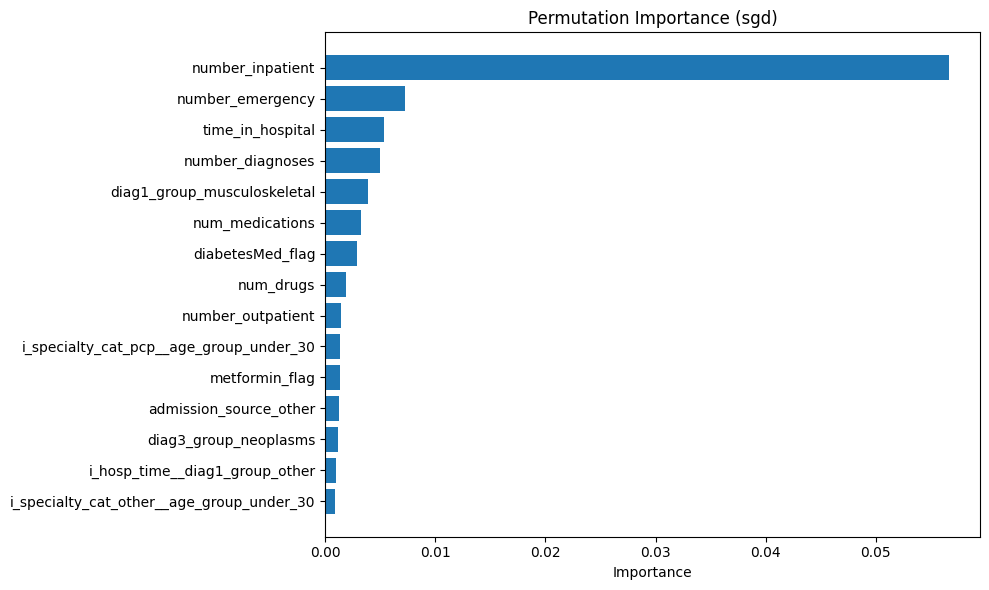

Duration: 0 hrs, 0 mins, 14.6 secs


In [ ]:
if not PCA:
    sgd_pipe.permute_importance()

In [17]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.577 0.574 0.573 0.566 0.553]
mean roc_auc score: , 0.569
-----Undersample Baseline-----
roc_auc score per fold:  [0.612 0.596 0.607 0.585 0.548]
mean roc_auc score: , 0.590
Duration: 0 hrs, 0 mins, 12.1 secs


In [18]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Best ROC_AUC (cv): 0.6581801790202503
Best params: {'model__tol': 0.001, 'model__shuffle': True, 'model__penalty': 'l2', 'model__max_iter': 100, 'model__loss': 'hinge', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.1, 'model__eta0': 0.1, 'model__class_weight': None, 'model__average': 5, 'model__alpha': 0.0001}
logged hyperparameters
Duration: 0 hrs, 0 mins, 42.4 secs


In [19]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6405176322722399
Accuracy:      0.7113202790150432
F1 score:      0.25081788440567065
Precision:     0.17026946994373704
Recall:        0.4759933774834437

Confusion matrix:

TN: 7889, FP: 2802, FN: 633, TP: 575

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.74      0.82     10691
           1       0.17      0.48      0.25      1208

    accuracy                           0.71     11899
   macro avg       0.55      0.61      0.54     11899
weighted avg       0.85      0.71      0.76     11899



Best threshold (F2): -0.8412
Precision: 0.118  Recall: 0.863  F2: 0.382


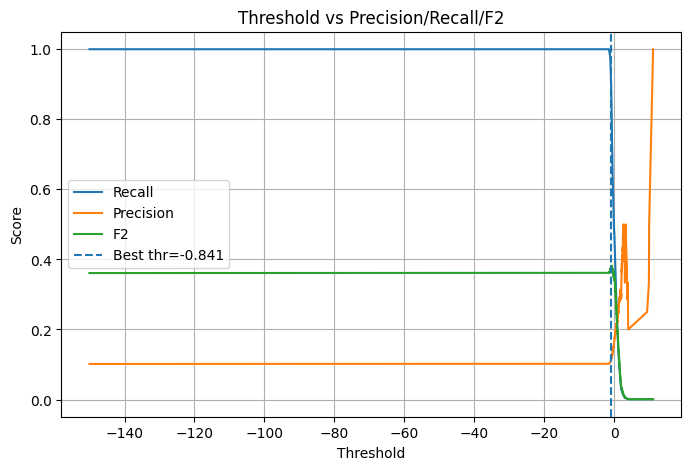

ROC_AUC:     0.6709448988643044
Accuracy:      0.33668384154067066
F1 score:      0.20071246819338423
Precision:     0.11367304588425178
Recall:        0.8566463944396178

Confusion matrix:

TN: 3000, FP: 7688, FN: 165, TP: 986

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.28      0.43     10688
           1       0.11      0.86      0.20      1151

    accuracy                           0.34     11839
   macro avg       0.53      0.57      0.32     11839
weighted avg       0.87      0.34      0.41     11839



In [20]:
sgd_pipe.test(show_duration_info=False)

# Support Vector Classifier

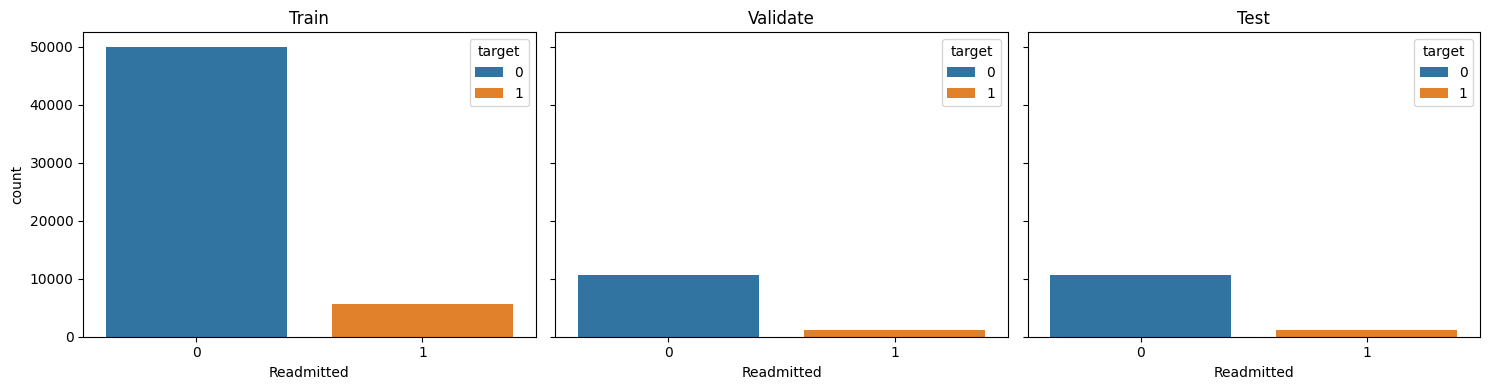

In [11]:
PCA = True
svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scale=True,
    use_pca=PCA
)

In [12]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.643 0.636 0.644 0.661 0.638]
mean roc_auc score: , 0.644
Duration: 0 hrs, 0 mins, 14.3 secs


In [19]:
# slow
# svc_pipe.permute_importance()

In [13]:
from scipy.stats import loguniform


# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

Best ROC_AUC (cv): 0.658676610741362
Best params: {'model__C': np.float64(4.418441521199722), 'model__class_weight': 'balanced', 'model__gamma': 0.001, 'model__kernel': 'rbf', 'model__shrinking': False}
logged hyperparameters
Duration: 0 hrs, 4 mins, 49.3 secs


In [14]:
svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6394792828776572
Accuracy:      0.707958651987562
F1 score:      0.24767265641913835
Precision:     0.16769275872178246
Recall:        0.4735099337748344

Confusion matrix:

TN: 7852, FP: 2839, FN: 636, TP: 572

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.73      0.82     10691
           1       0.17      0.47      0.25      1208

    accuracy                           0.71     11899
   macro avg       0.55      0.60      0.53     11899
weighted avg       0.85      0.71      0.76     11899



Best threshold (F2): -0.6370
Precision: 0.130  Recall: 0.734  F2: 0.380


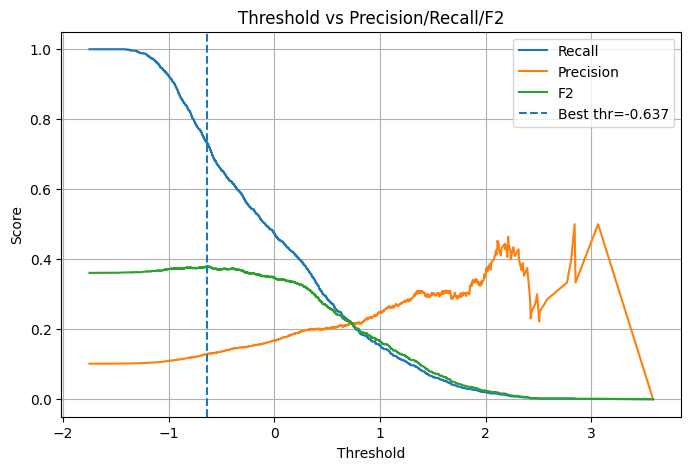

ROC_AUC:     0.6749646070586889
Accuracy:      0.4802770504265563
F1 score:      0.2208433582373053
Precision:     0.12926178476134007
Recall:        0.7576020851433536

Confusion matrix:

TN: 4814, FP: 5874, FN: 279, TP: 872

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.45      0.61     10688
           1       0.13      0.76      0.22      1151

    accuracy                           0.48     11839
   macro avg       0.54      0.60      0.42     11839
weighted avg       0.87      0.48      0.57     11839



In [15]:
svc_pipe.test()

# XGBoost

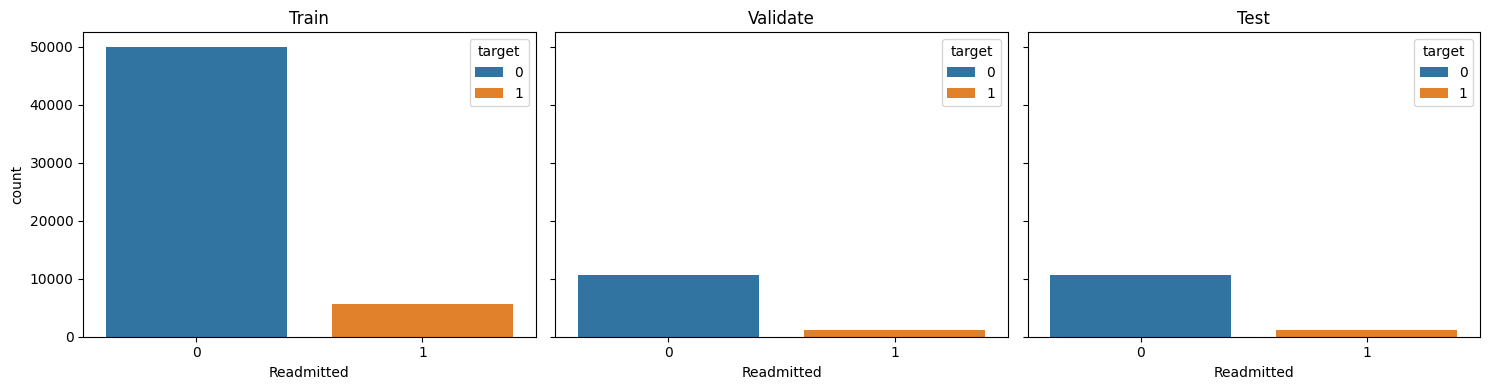

In [6]:
PCA = True

xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=True,
    log_transform_cols=LOG_TRANSFORM_COLS,
    use_pca=PCA
)

In [4]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.621 0.611 0.6   0.62  0.606]
mean roc_auc score: , 0.612
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.622 0.62  0.618 0.634 0.623]
mean roc_auc score: , 0.623
Duration: 0 hrs, 0 mins, 16.1 secs


In [7]:
if not PCA:
    xgb_pipe.permute_importance()

In [8]:
from scipy.stats import randint, uniform, loguniform

approx_spw = float(8.9494) # from data exploration aprox inverse of class balance


param_dist = {
    'model__n_estimators': randint(200, 1500),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__max_depth': randint(2, 10),
    'model__min_child_weight': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': loguniform(max(approx_spw/5, 1e-3), approx_spw*5),
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Best ROC_AUC (cv): 0.5309308259321335
Best params: {'model__colsample_bytree': np.float64(0.6872700594236812), 'model__gamma': np.float64(4.75357153204958), 'model__learning_rate': np.float64(0.22227824312530747), 'model__max_depth': 6, 'model__min_child_weight': 5, 'model__n_estimators': 321, 'model__reg_alpha': np.float64(1.23583827723069e-07), 'model__reg_lambda': np.float64(0.014936568554617643), 'model__scale_pos_weight': np.float64(29.0861476250946), 'model__subsample': np.float64(0.8005575058716043)}
logged hyperparameters
Duration: 0 hrs, 1 mins, 3.5 secs


In [9]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.5404533103600788
Accuracy:      0.11874947474577696
F1 score:      0.18523698523698523
Precision:     0.1022123134968273
Recall:        0.9867549668874173

Confusion matrix:

TN: 221, FP: 10470, FN: 16, TP: 1192

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.02      0.04     10691
           1       0.10      0.99      0.19      1208

    accuracy                           0.12     11899
   macro avg       0.52      0.50      0.11     11899
weighted avg       0.85      0.12      0.06     11899



Best threshold (F2): 0.5149
Precision: 0.102  Recall: 0.987  F2: 0.362


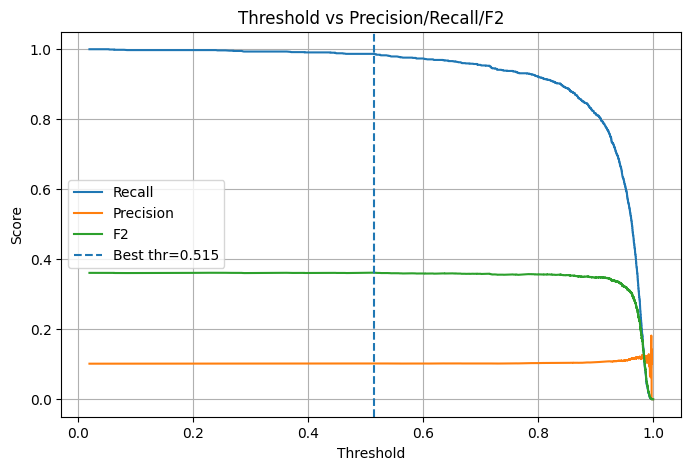

ROC_AUC:     0.5245245689116989
Accuracy:      0.1190134301883605
F1 score:      0.17848141146817895
Precision:     0.09813772195755738
Recall:        0.9843614248479583

Confusion matrix:

TN: 276, FP: 10412, FN: 18, TP: 1133

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.03      0.05     10688
           1       0.10      0.98      0.18      1151

    accuracy                           0.12     11839
   macro avg       0.52      0.51      0.11     11839
weighted avg       0.86      0.12      0.06     11839



In [10]:
xgb_pipe.test()